# Using Jupyter as the Foundation of my analysis

Notebook inicial para explorar los pedidos de los ultimos 30 dias y preparar el analisis.

**Limitacion:** el CSV contiene fecha de creacion del pedido, pero no fechas de envio o entrega; con estos datos no se puede estimar una ETA de entrega.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


csv_path = Path("dash_orders_30_days_sample.csv")
orders = pd.read_csv(csv_path, parse_dates=["order_created_at"])

print(f"Filas: {orders.shape[0]:,} | Columnas: {orders.shape[1]}")
print("Columnas:", orders.columns.tolist())
orders.head()

Filas: 1,524 | Columnas: 8
Columnas: ['order_id', 'order_created_at', 'sku', 'order_type', 'quantity', 'net_sales_usd', 'financial_status', 'fulfillment_status']


,order_id,order_created_at,sku,order_type,quantity,net_sales_usd,financial_status,fulfillment_status
0,DASH-2001,2025-04-01 08:00:00+00:00,FRESH-8LB-BEEF-CHICKEN,trial,1,34.5,paid,fulfilled
1,DASH-2002,2025-04-01 09:07:00+00:00,FRESH-8LB-BEEF-CHICKEN,trial,1,34.5,paid,fulfilled
2,DASH-2003,2025-04-01 10:14:00+00:00,FRESH-8LB-BEEF-CHICKEN,trial,1,34.5,paid,fulfilled
3,DASH-2004,2025-04-01 11:21:00+00:00,FRESH-8LB-BEEF-CHICKEN,subscription,1,127.2,paid,fulfilled
4,DASH-2005,2025-04-01 12:28:00+00:00,FRESH-8LB-BEEF-CHICKEN,subscription,1,127.2,paid,fulfilled


In [3]:
daily_sales = (
    orders.assign(date=orders["order_created_at"].dt.date)
    .groupby("date", as_index=False)
    .agg(
        total_sales=("net_sales_usd", "sum"),
        quantity=("quantity", "sum"),
    )
    .sort_values("date")
)

daily_sales

,date,total_sales,quantity
0,2025-04-01,5605.5,55
1,2025-04-02,5605.5,55
2,2025-04-03,5478.3,54
3,2025-04-04,5351.1,53
4,2025-04-05,5351.1,53
5,2025-04-06,5351.1,53
6,2025-04-07,5351.1,53
7,2025-04-08,5478.3,54
8,2025-04-09,5605.5,55
9,2025-04-10,5605.5,55


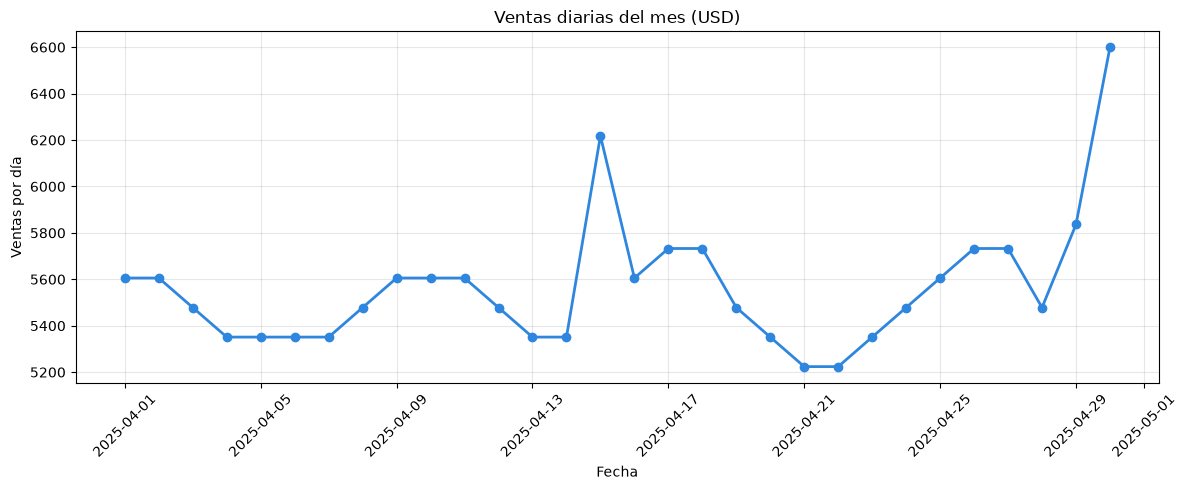

In [4]:

plt.figure(figsize=(12, 5))
plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    marker="o",
    linewidth=2,
    color="#2E86DE"
)
plt.title("Ventas diarias del mes (USD)")
plt.xlabel("Fecha")
plt.ylabel("Ventas por día")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
historical_day = pd.to_datetime(daily_sales["date"]).dt.day
regular_demand = daily_sales.loc[~historical_day.isin([15, 30]), "quantity"]
basic_daily_demand = regular_demand.mean()
growth_rate = 0.25

day_15_units = daily_sales.loc[historical_day.eq(15), "quantity"].iloc[0]
day_30_units = daily_sales.loc[historical_day.eq(30), "quantity"].iloc[0]
day_15_factor = day_15_units / basic_daily_demand
day_30_factor = day_30_units / basic_daily_demand

forecast_dates = pd.date_range(
    start=pd.to_datetime(daily_sales["date"].max()) + pd.Timedelta(days=1),
    periods=30,
    freq="D",
)
forecast = pd.DataFrame(
    {
        "forecast_day": range(1, 31),
        "date": forecast_dates,
    }
)
forecast["demand_factor"] = forecast["forecast_day"].map(
    {15: day_15_factor, 30: day_30_factor}
).fillna(1.0)
forecast["forecast_units"] = (
    basic_daily_demand * (1 + growth_rate) * forecast["demand_factor"]
)

print(f"Basic daily demand (excluding days 15 and 30): {basic_daily_demand:.2f} units")
print(f"Growth assumption: {growth_rate:.0%}")
print(f"Day 15 factor: {day_15_factor:.3f} (historical demand: {day_15_units:.0f})")
print(f"Day 30 factor: {day_30_factor:.3f} (historical demand: {day_30_units:.0f})")
print(f"Total forecast demand with growth: {forecast['forecast_units'].sum():.2f} units")
forecast.round({"demand_factor": 3, "forecast_units": 2})

Basic daily demand (excluding days 15 and 30): 54.29 units
Growth assumption: 25%
Day 15 factor: 1.142 (historical demand: 62)
Day 30 factor: 1.197 (historical demand: 65)
Total forecast demand with growth: 2058.75 units


,forecast_day,date,demand_factor,forecast_units
0,1,2025-05-01,1.000,67.86
1,2,2025-05-02,1.000,67.86
2,3,2025-05-03,1.000,67.86
3,4,2025-05-04,1.000,67.86
4,5,2025-05-05,1.000,67.86
5,6,2025-05-06,1.000,67.86
6,7,2025-05-07,1.000,67.86
7,8,2025-05-08,1.000,67.86
8,9,2025-05-09,1.000,67.86
9,10,2025-05-10,1.000,67.86


In [6]:
actual_recent_7d = daily_sales.tail(7)
actual_7d_average = actual_recent_7d["quantity"].mean()
forecast_next_7d = forecast.head(7)
forecast_next_7d_average = forecast_next_7d["forecast_units"].mean()

comparison = pd.DataFrame(
    [
        {
            "period": "Actual: latest 7 days",
            "start_date": actual_recent_7d["date"].iloc[0],
            "end_date": actual_recent_7d["date"].iloc[-1],
            "total_units": actual_recent_7d["quantity"].sum(),
            "average_units_per_day": actual_7d_average,
        },
        {
            "period": "Forecast: next 7 days",
            "start_date": forecast_next_7d["date"].iloc[0].date(),
            "end_date": forecast_next_7d["date"].iloc[-1].date(),
            "total_units": forecast_next_7d["forecast_units"].sum(),
            "average_units_per_day": forecast_next_7d_average,
        },
        {
            "period": "Forecast: next 30 days",
            "start_date": forecast["date"].iloc[0].date(),
            "end_date": forecast["date"].iloc[-1].date(),
            "total_units": forecast["forecast_units"].sum(),
            "average_units_per_day": forecast["forecast_units"].mean(),
        },
    ]
)

change_pct = (forecast_next_7d_average / actual_7d_average - 1) * 100
print(f"Next 7-day forecast vs latest 7-day actual: {change_pct:+.2f}% average units/day")
comparison.round({"total_units": 2, "average_units_per_day": 2})

Next 7-day forecast vs latest 7-day actual: +19.05% average units/day


,period,start_date,end_date,total_units,average_units_per_day
0,Actual: latest 7 days,2025-04-24,2025-04-30,399.00,57.00
1,Forecast: next 7 days,2025-05-01,2025-05-07,475.00,67.86
2,Forecast: next 30 days,2025-05-01,2025-05-30,2058.75,68.63


In [7]:
empty_cells = orders.isna().copy()

for column in orders.select_dtypes(include=["object", "string"]).columns:
    empty_cells[column] |= orders[column].astype("string").str.strip().eq("").fillna(False)

empty_pct_by_row = empty_cells.mean(axis=1) * 100
rows_over_50 = orders.loc[empty_pct_by_row > 50].copy()
rows_over_50["empty_pct"] = empty_pct_by_row[empty_pct_by_row > 50]

display(rows_over_50)

if not rows_over_50.empty:
    plt.figure(figsize=(10, max(4, len(rows_over_50) * 0.3)))
    plt.barh(rows_over_50.index.astype(str), rows_over_50["empty_pct"], color="#2E86DE")
    plt.axvline(50, color="red", linestyle="--", label="50%")
    plt.xlabel("Empty values (%)")
    plt.ylabel("Row index")
    plt.title("Rows with more than 50% empty values")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rows have more than 50% empty values.")

,order_id,order_created_at,sku,order_type,quantity,net_sales_usd,financial_status,fulfillment_status,empty_pct


No rows have more than 50% empty values.
